# BCG's Data Science job simulation

## customer churn analysis simulation using Python.

In [2]:
#Import package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report

In [10]:
# Visualization Configuration
%matplotlib inline
sns.set(color_codes=True)

# ==========================================
# 1. LOADING DATA
# ==========================================
client_df = pd.read_csv('client_data.csv')
price_df = pd.read_csv('price_data.csv')

## EDA

--- Statistik Deskriptif Client Data ---


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


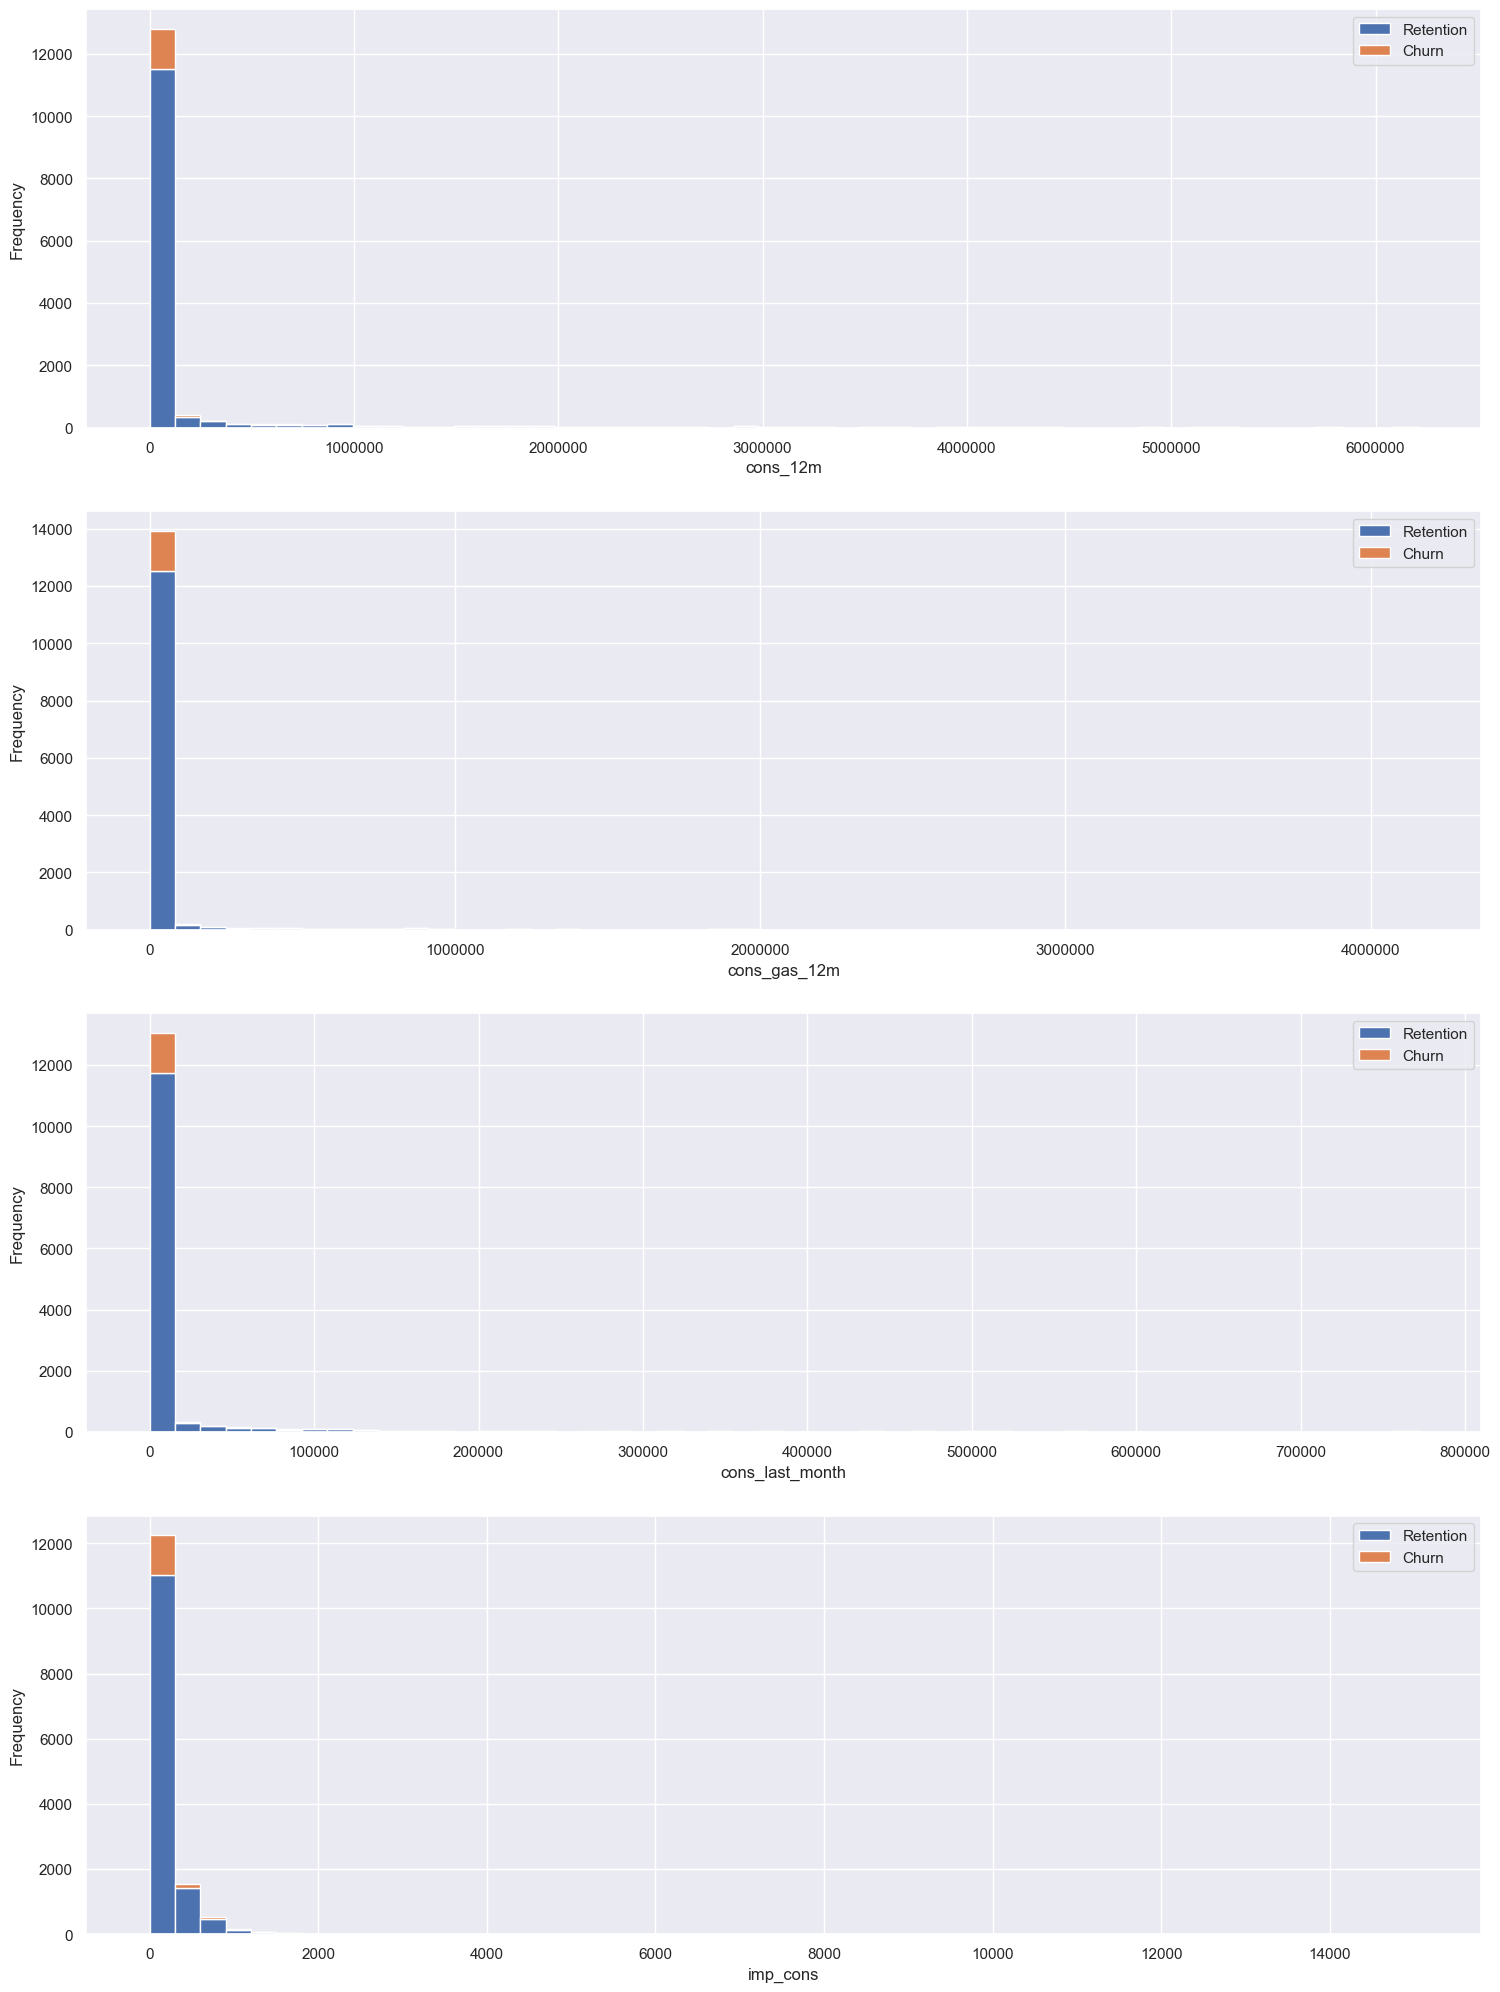

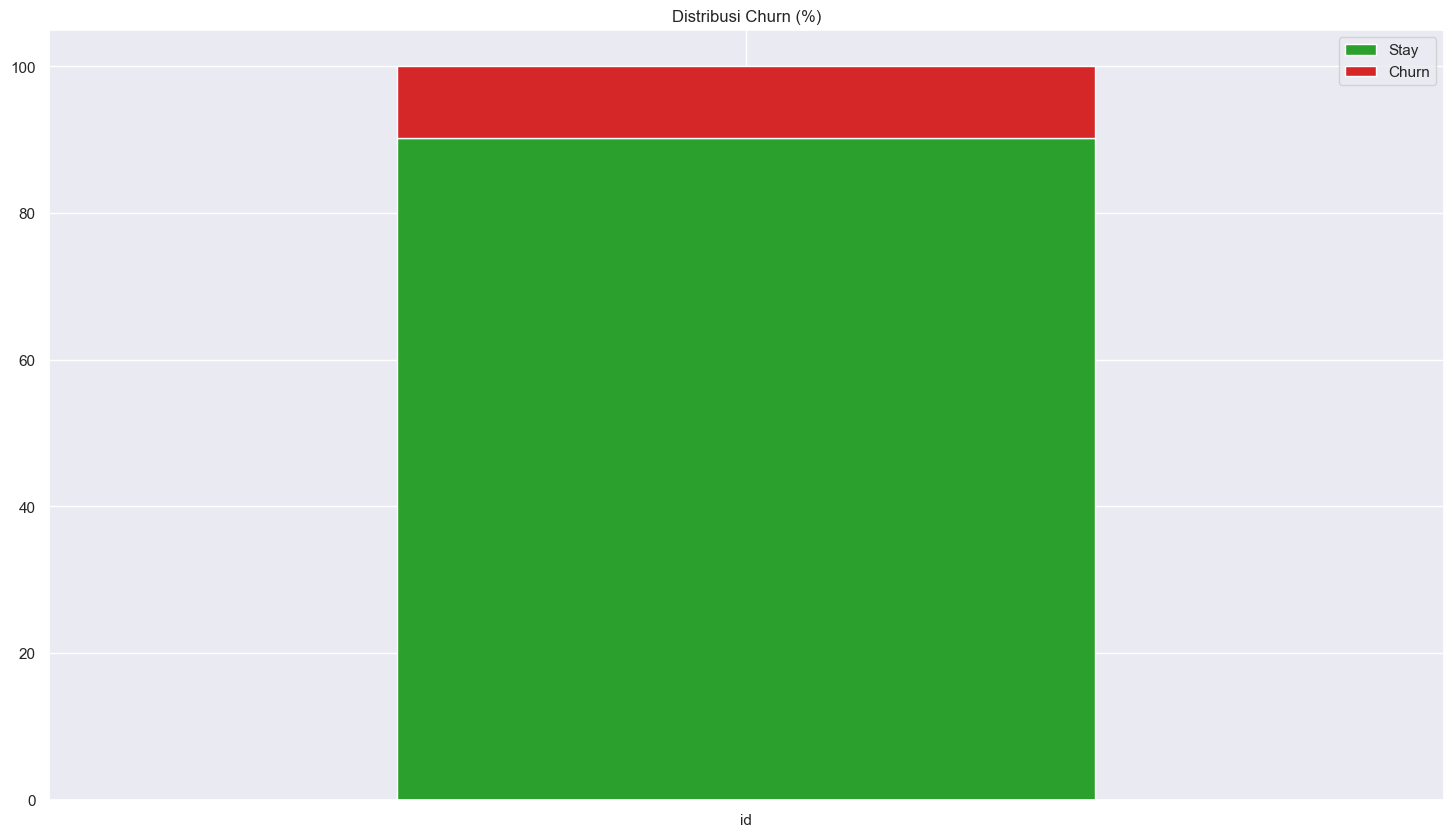

In [11]:
# Statistical Summary
print("--- Statistik Deskriptif Client Data ---")
display(client_df.describe())

# Visualization of Churn Distribution
def plot_stacked_bar(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    ax = dataframe.plot(kind="bar", stacked=True, figsize=size_, rot=rot_, color=['#2ca02c', '#d62728'])
    plt.legend(["Stay", "Churn"], loc=legend_)
    plt.title(title_)
    plt.show()

churn = client_df[['id', 'churn']]
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bar(churn_percentage.transpose(), "Distribusi Churn (%)")

# Energy Consumption Analysis
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

def plot_distribution(dataframe, column, ax, bins_=50):
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
                         "Churn": dataframe[dataframe["churn"]==1][column]})
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    ax.set_xlabel(column)
    ax.ticklabel_format(style='plain', axis='x')

fig, axs = plt.subplots(nrows=4, figsize=(18, 25))
plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption, 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])

## Feature Engineering

In [12]:
# Date Conversion
client_df["date_activ"] = pd.to_datetime(client_df["date_activ"], format='%Y-%m-%d')
client_df["date_end"] = pd.to_datetime(client_df["date_end"], format='%Y-%m-%d')
client_df["date_modif_prod"] = pd.to_datetime(client_df["date_modif_prod"], format='%Y-%m-%d')
client_df["date_renewal"] = pd.to_datetime(client_df["date_renewal"], format='%Y-%m-%d')
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')

# Creating a Price Change Feature (Estelle's Idea)
# Calculating the average price per period
mean_prices = price_df.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

# Calculating the difference between the December and January prices
jan_prices = price_df[jan_mask].groupby('id').mean().reset_index()

# For December prices
dec_mask = price_df['price_date'].dt.month == 12
dec_prices = price_df[dec_mask].groupby('id').mean().reset_index()

# The rest of the code remains the same
diff = pd.merge(jan_prices[['id', 'price_off_peak_var', 'price_off_peak_fix']], 
                dec_prices[['id', 'price_off_peak_var', 'price_off_peak_fix']], on='id', suffixes=('_jan', '_dec'))

diff['offpeak_diff_dec_january_energy'] = diff['price_off_peak_var_dec'] - diff['price_off_peak_var_jan']
diff['offpeak_diff_dec_january_power'] = diff['price_off_peak_fix_dec'] - diff['price_off_peak_fix_jan']

# Merging Features into the Main Dataset
df = pd.merge(client_df, diff[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']], on='id')

# Transformasi Variabel Kategorikal (Dummy Encoding)
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])
df = pd.get_dummies(df, columns=['channel_sales'], prefix='channel')
df = pd.get_dummies(df, columns=['origin_up'], prefix='origin')

# Calculating Tenure (Subscription Period)
df['tenure'] = ((df['date_end'] - df['date_activ']).dt.days / 365).astype(int)

# Removing columns not needed for modeling
df.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_9512\3107199247.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])


## Modeling & Evaluation


--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3300
           1       0.89      0.05      0.09       346

    accuracy                           0.91      3646
   macro avg       0.90      0.52      0.52      3646
weighted avg       0.91      0.91      0.87      3646



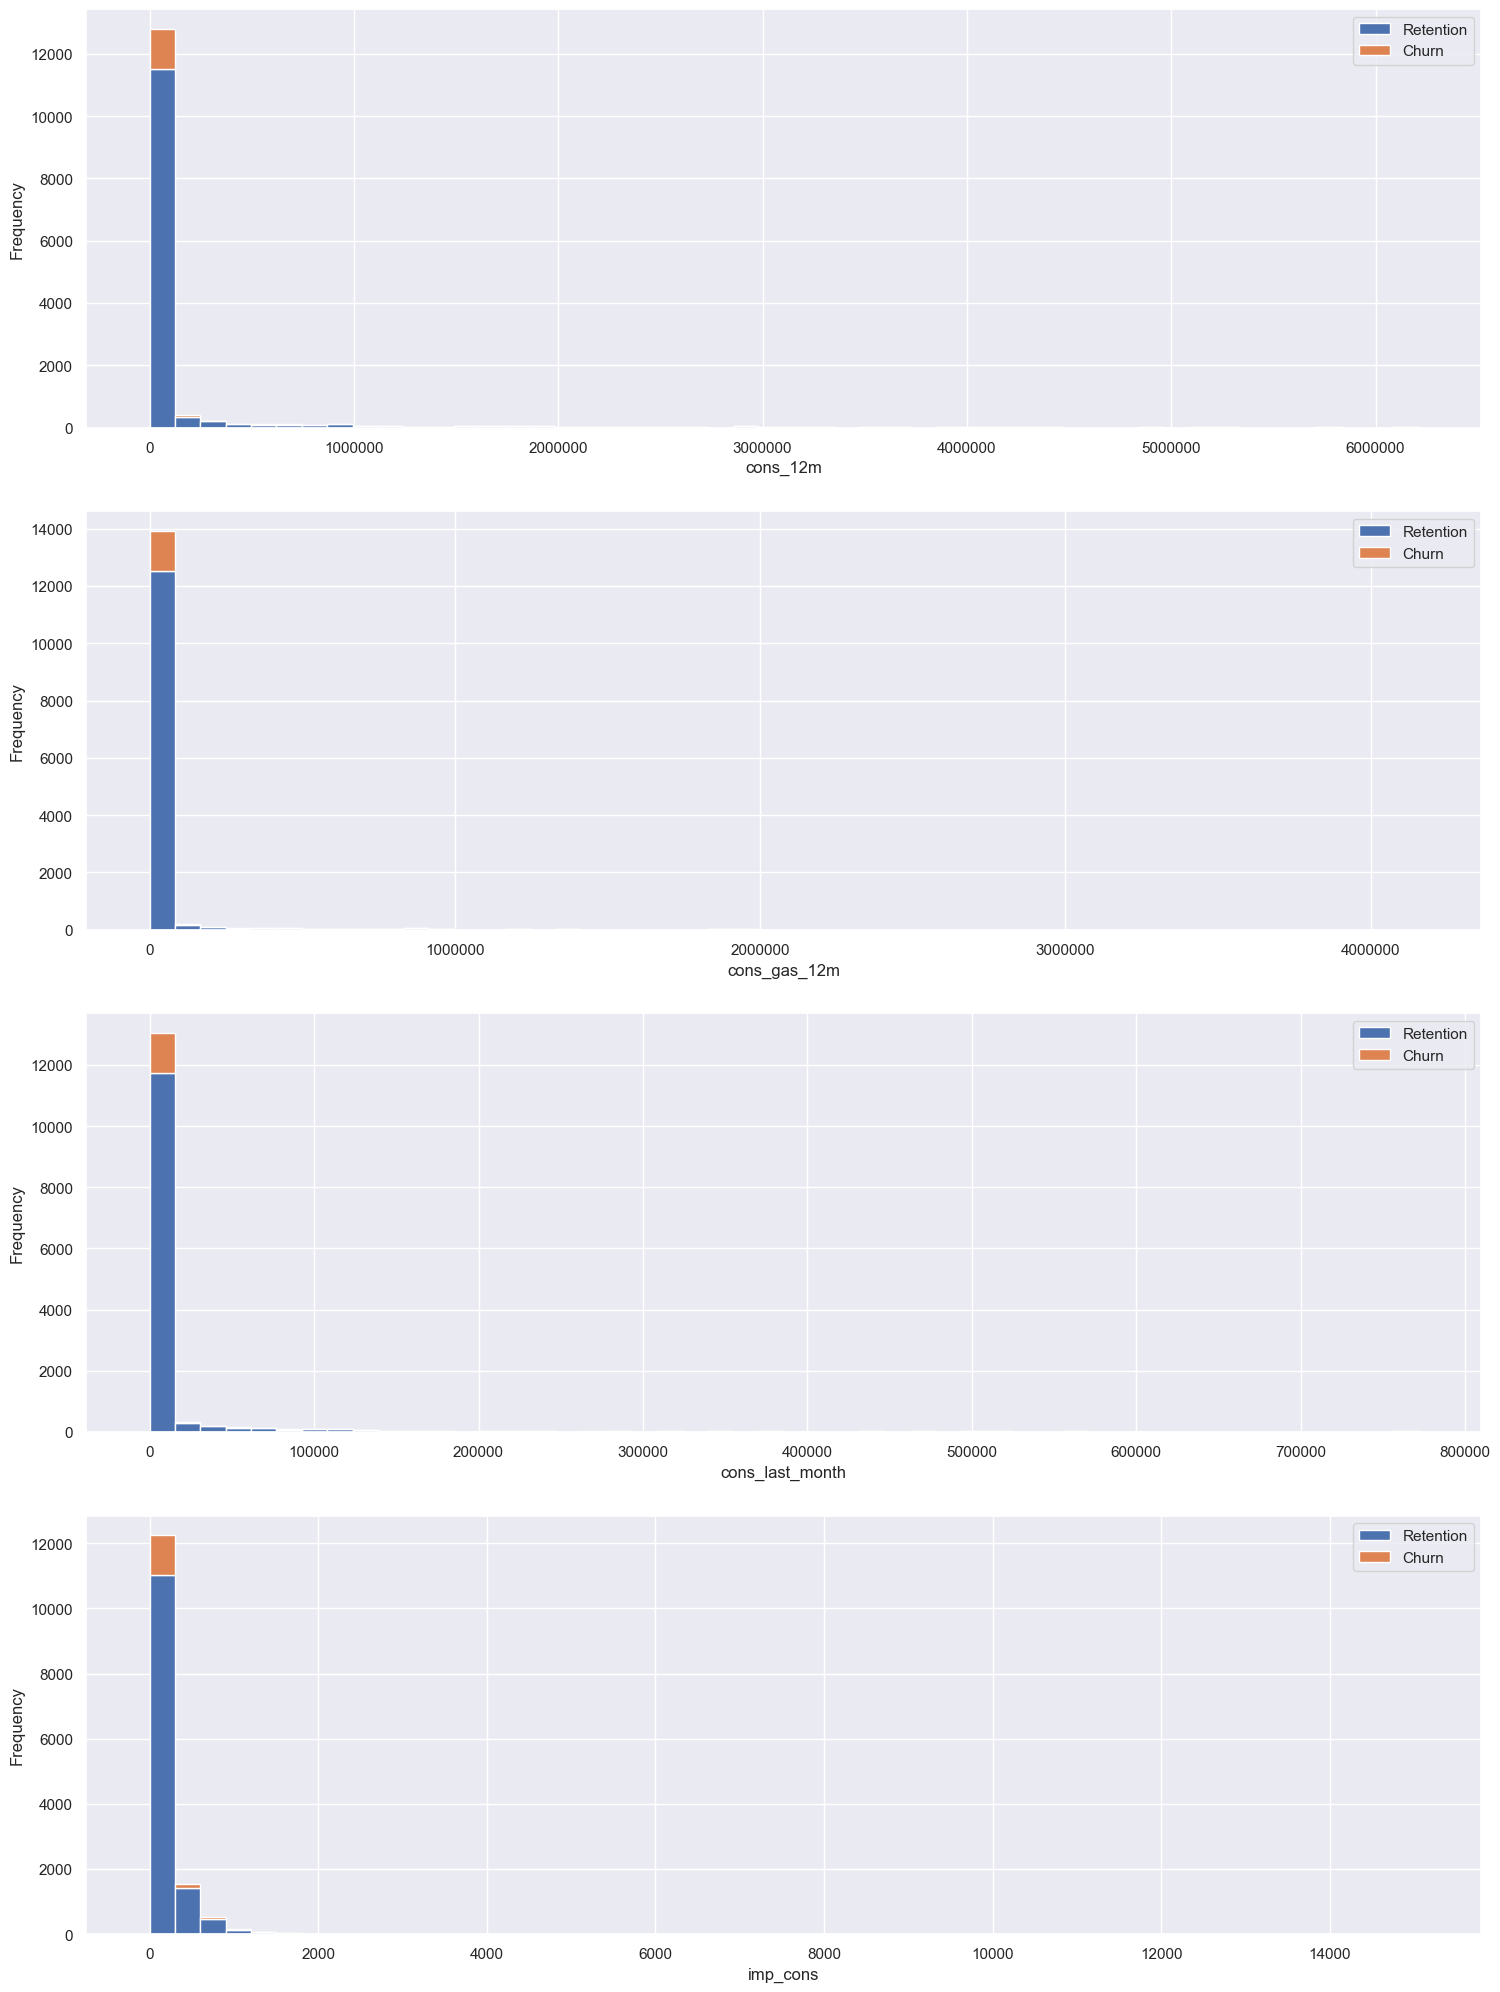

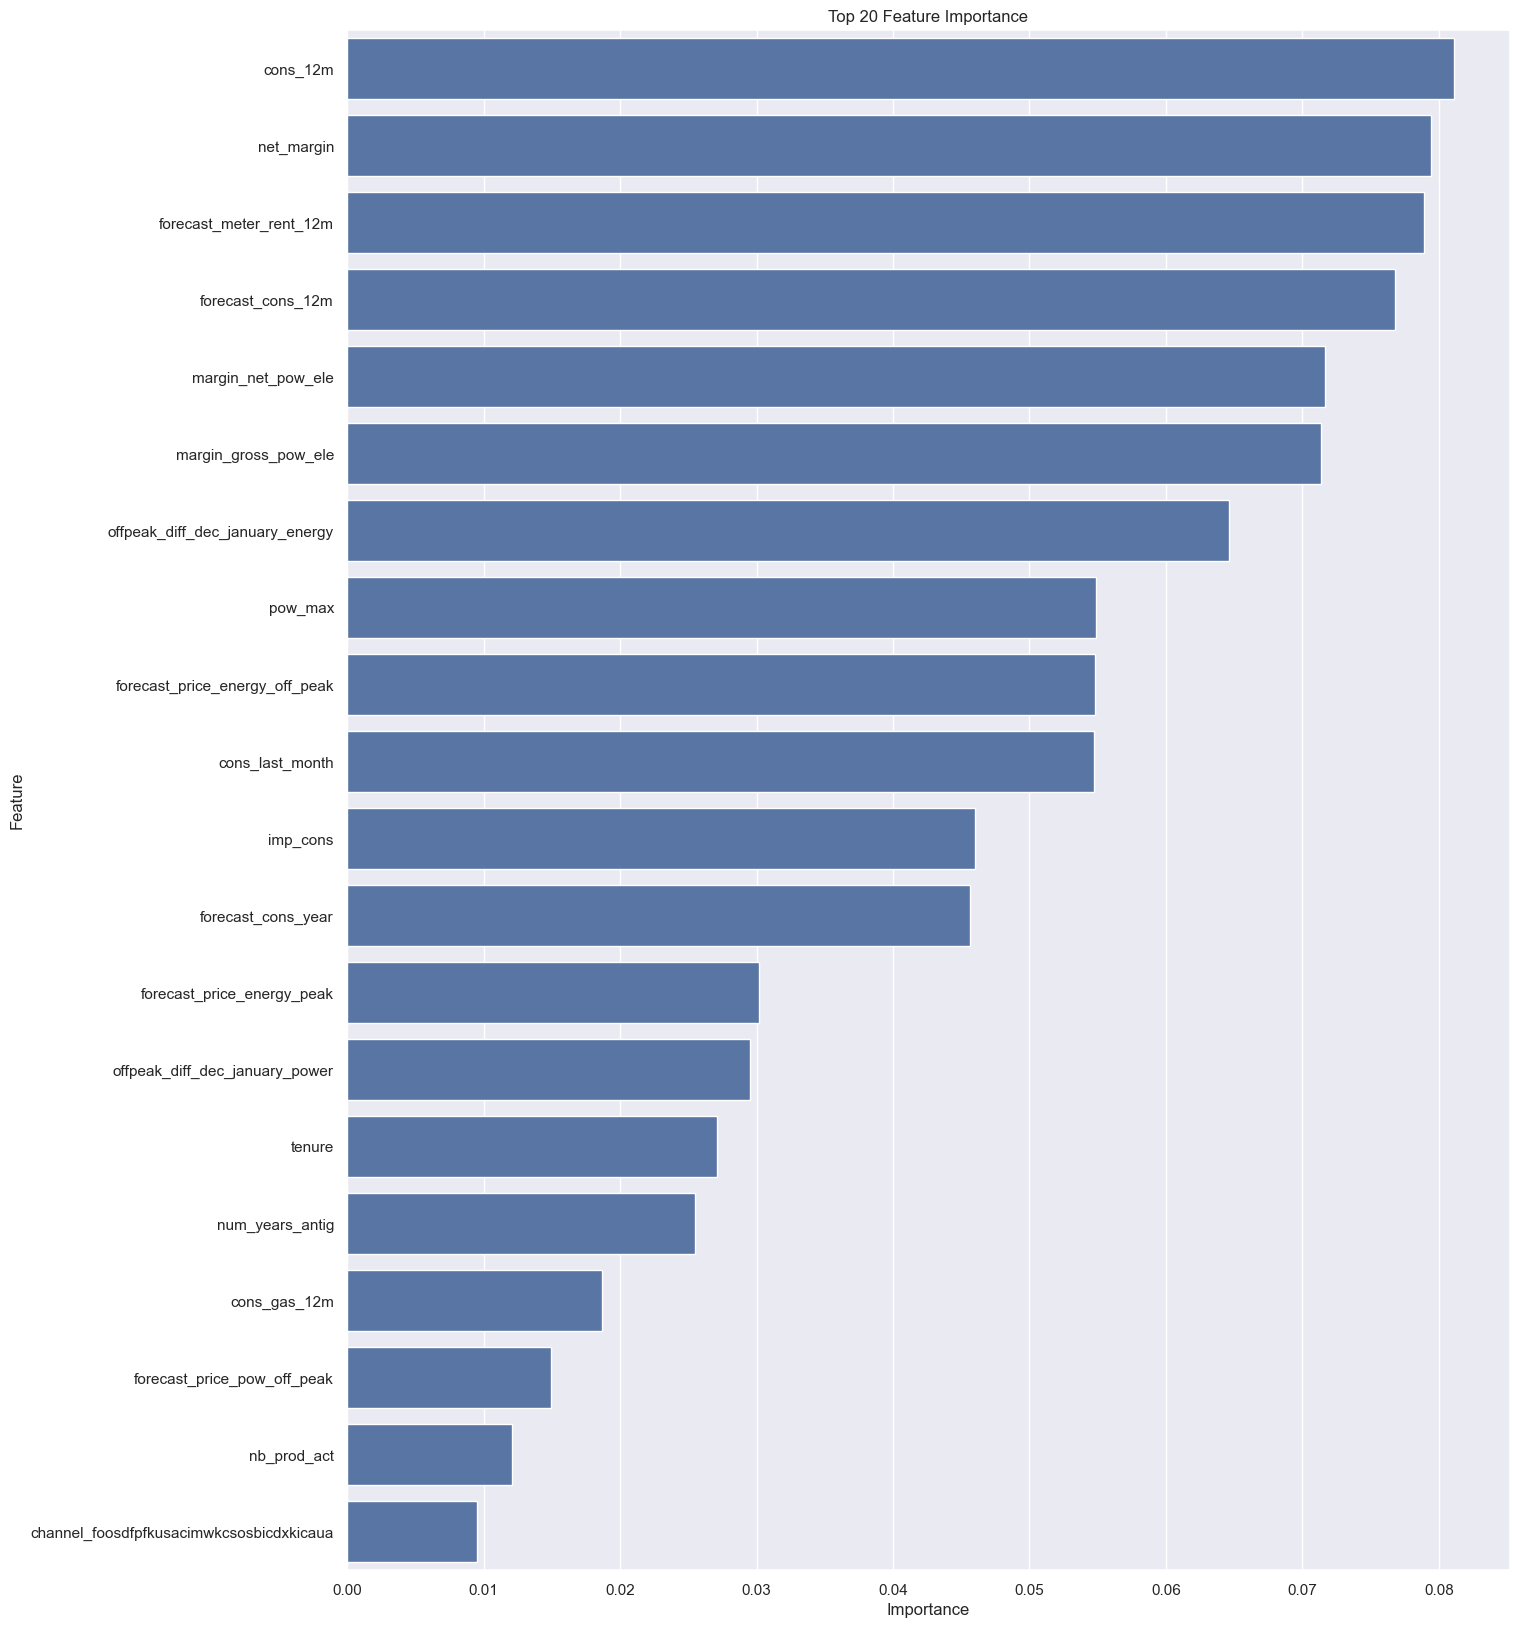

Model Accuracy: 0.9089


In [13]:
# Preparation of Training and Testing Data
X = df.drop(columns=['id', 'churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Training Model Random Forest
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

# Model Evaluation
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_test, predictions))

# Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 20))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(20))
plt.title('Top 20 Feature Importance')
plt.show()

# Final Conclusion
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.4f}")